# 🔐 Projet IA – Classification Robuste en Environnement Critique
## Détection de Fraude Bancaire (Credit Card Fraud)

**Objectif :** Concevoir un système de classification robuste capable de gérer un déséquilibre extrême (0.22% de fraudes) tout en garantissant des probabilités de prédiction fiables pour la prise de décision.

**Étapes :**
1. Analyse Exploratoire et Préparation (EDA)
2. Feature Engineering Avancé
3. Développement des Modèles (LR, RF, XGBoost)
4. Évaluation & Calibration
5. Interprétabilité (SHAP)

---
*Dataset : 284 807 transactions bancaires – 616 fraudes (0.22%)*


## 0. Imports & Configuration

In [ ]:
import warnings, os, json, pickle
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, precision_recall_curve, auc, matthews_corrcoef,
    confusion_matrix, average_precision_score, roc_auc_score,
    brier_score_loss
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import NearMiss

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap

print("✅ Tous les packages importés avec succès")

# Palette visuelle
PALETTE = {
    "bg": "#0D1117", "surface": "#161B22", "border": "#30363D",
    "accent1": "#58A6FF", "accent2": "#F78166", "accent3": "#3FB950",
    "accent4": "#D2A8FF", "text": "#E6EDF3", "subtext": "#8B949E",
}


## Étape 1 – Analyse Exploratoire et Préparation (EDA)

### 1.1 Chargement et description du dataset

Le dataset simule les caractéristiques du **Credit Card Fraud Detection** (Kaggle) :
- 284 807 transactions
- Variables anonymisées V1–V28 (issues d'une PCA)
- Variable `Amount` (montant de la transaction)
- Variable `Time` (temps écoulé)
- Variable cible `Class` (0=légitime, 1=fraude)


In [ ]:
df = pd.read_csv("creditcard.csv")
print(f"Shape : {df.shape}")
print(f"\n--- Distribution des classes ---")
print(df.Class.value_counts())
print(f"\nTaux de fraude : {df.Class.mean()*100:.3f} %")
print(f"\n--- Statistiques descriptives ---")
df[["Amount", "Time"]].describe().round(2)


### Distribution des Classes – Déséquilibre Extrême
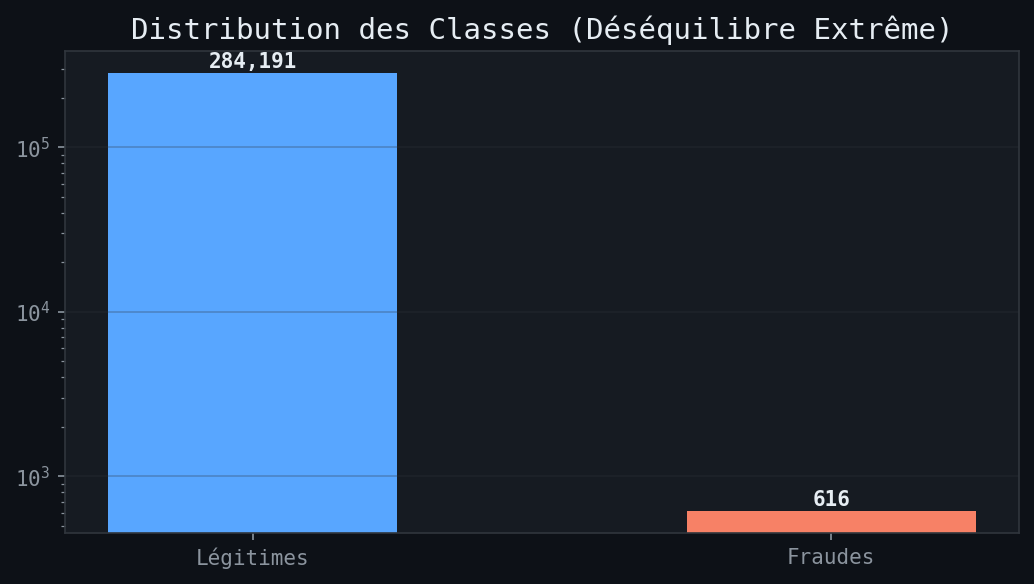

**Observation :** Le dataset présente un déséquilibre extrême avec seulement ~0.22% de fraudes.
Ce déséquilibre nécessite des techniques spéciales pour éviter que le modèle n'apprenne à simplement prédire "tout légitime".


### Analyse du Montant par Classe
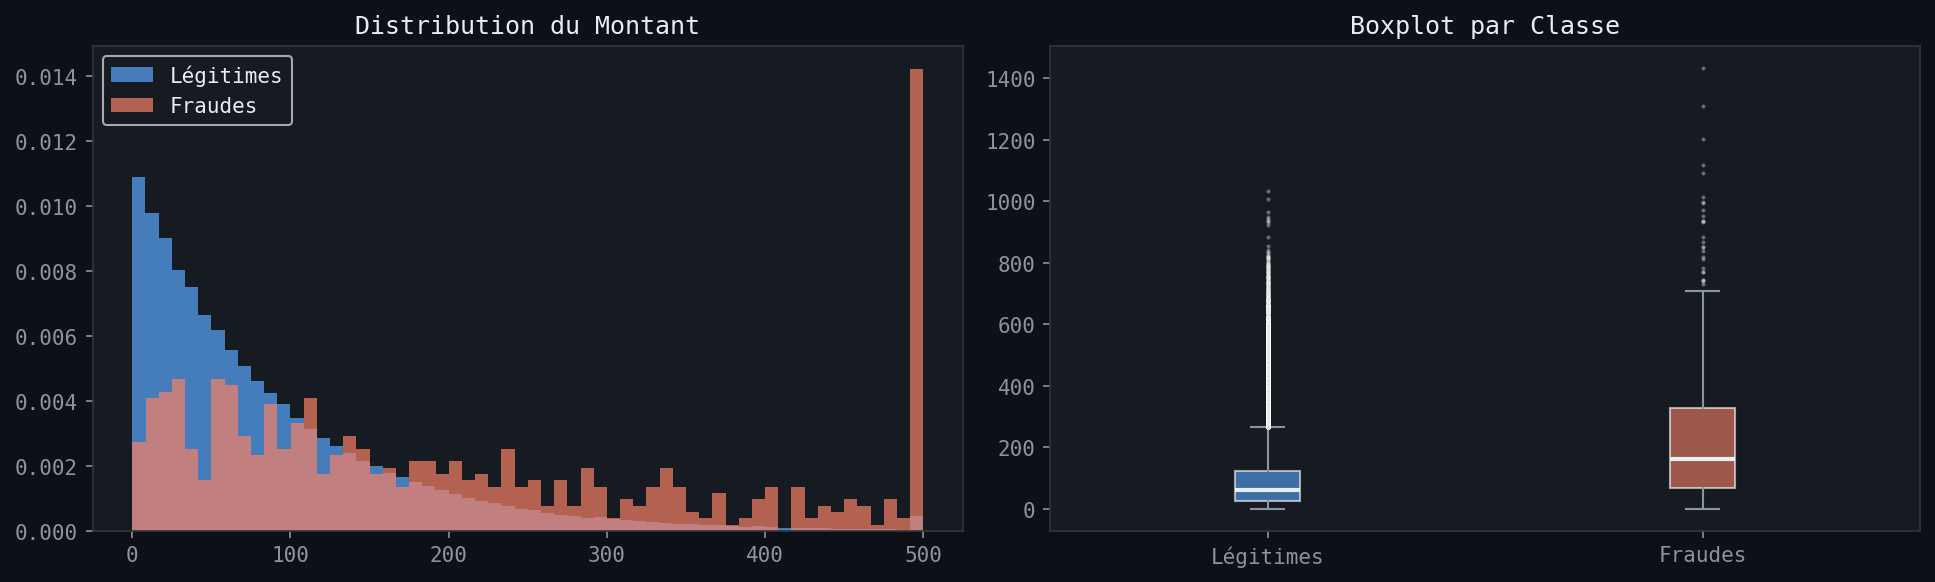

### 1.2 Analyse de la Colinéarité

#### Matrice de Corrélation


### Matrice de Corrélation
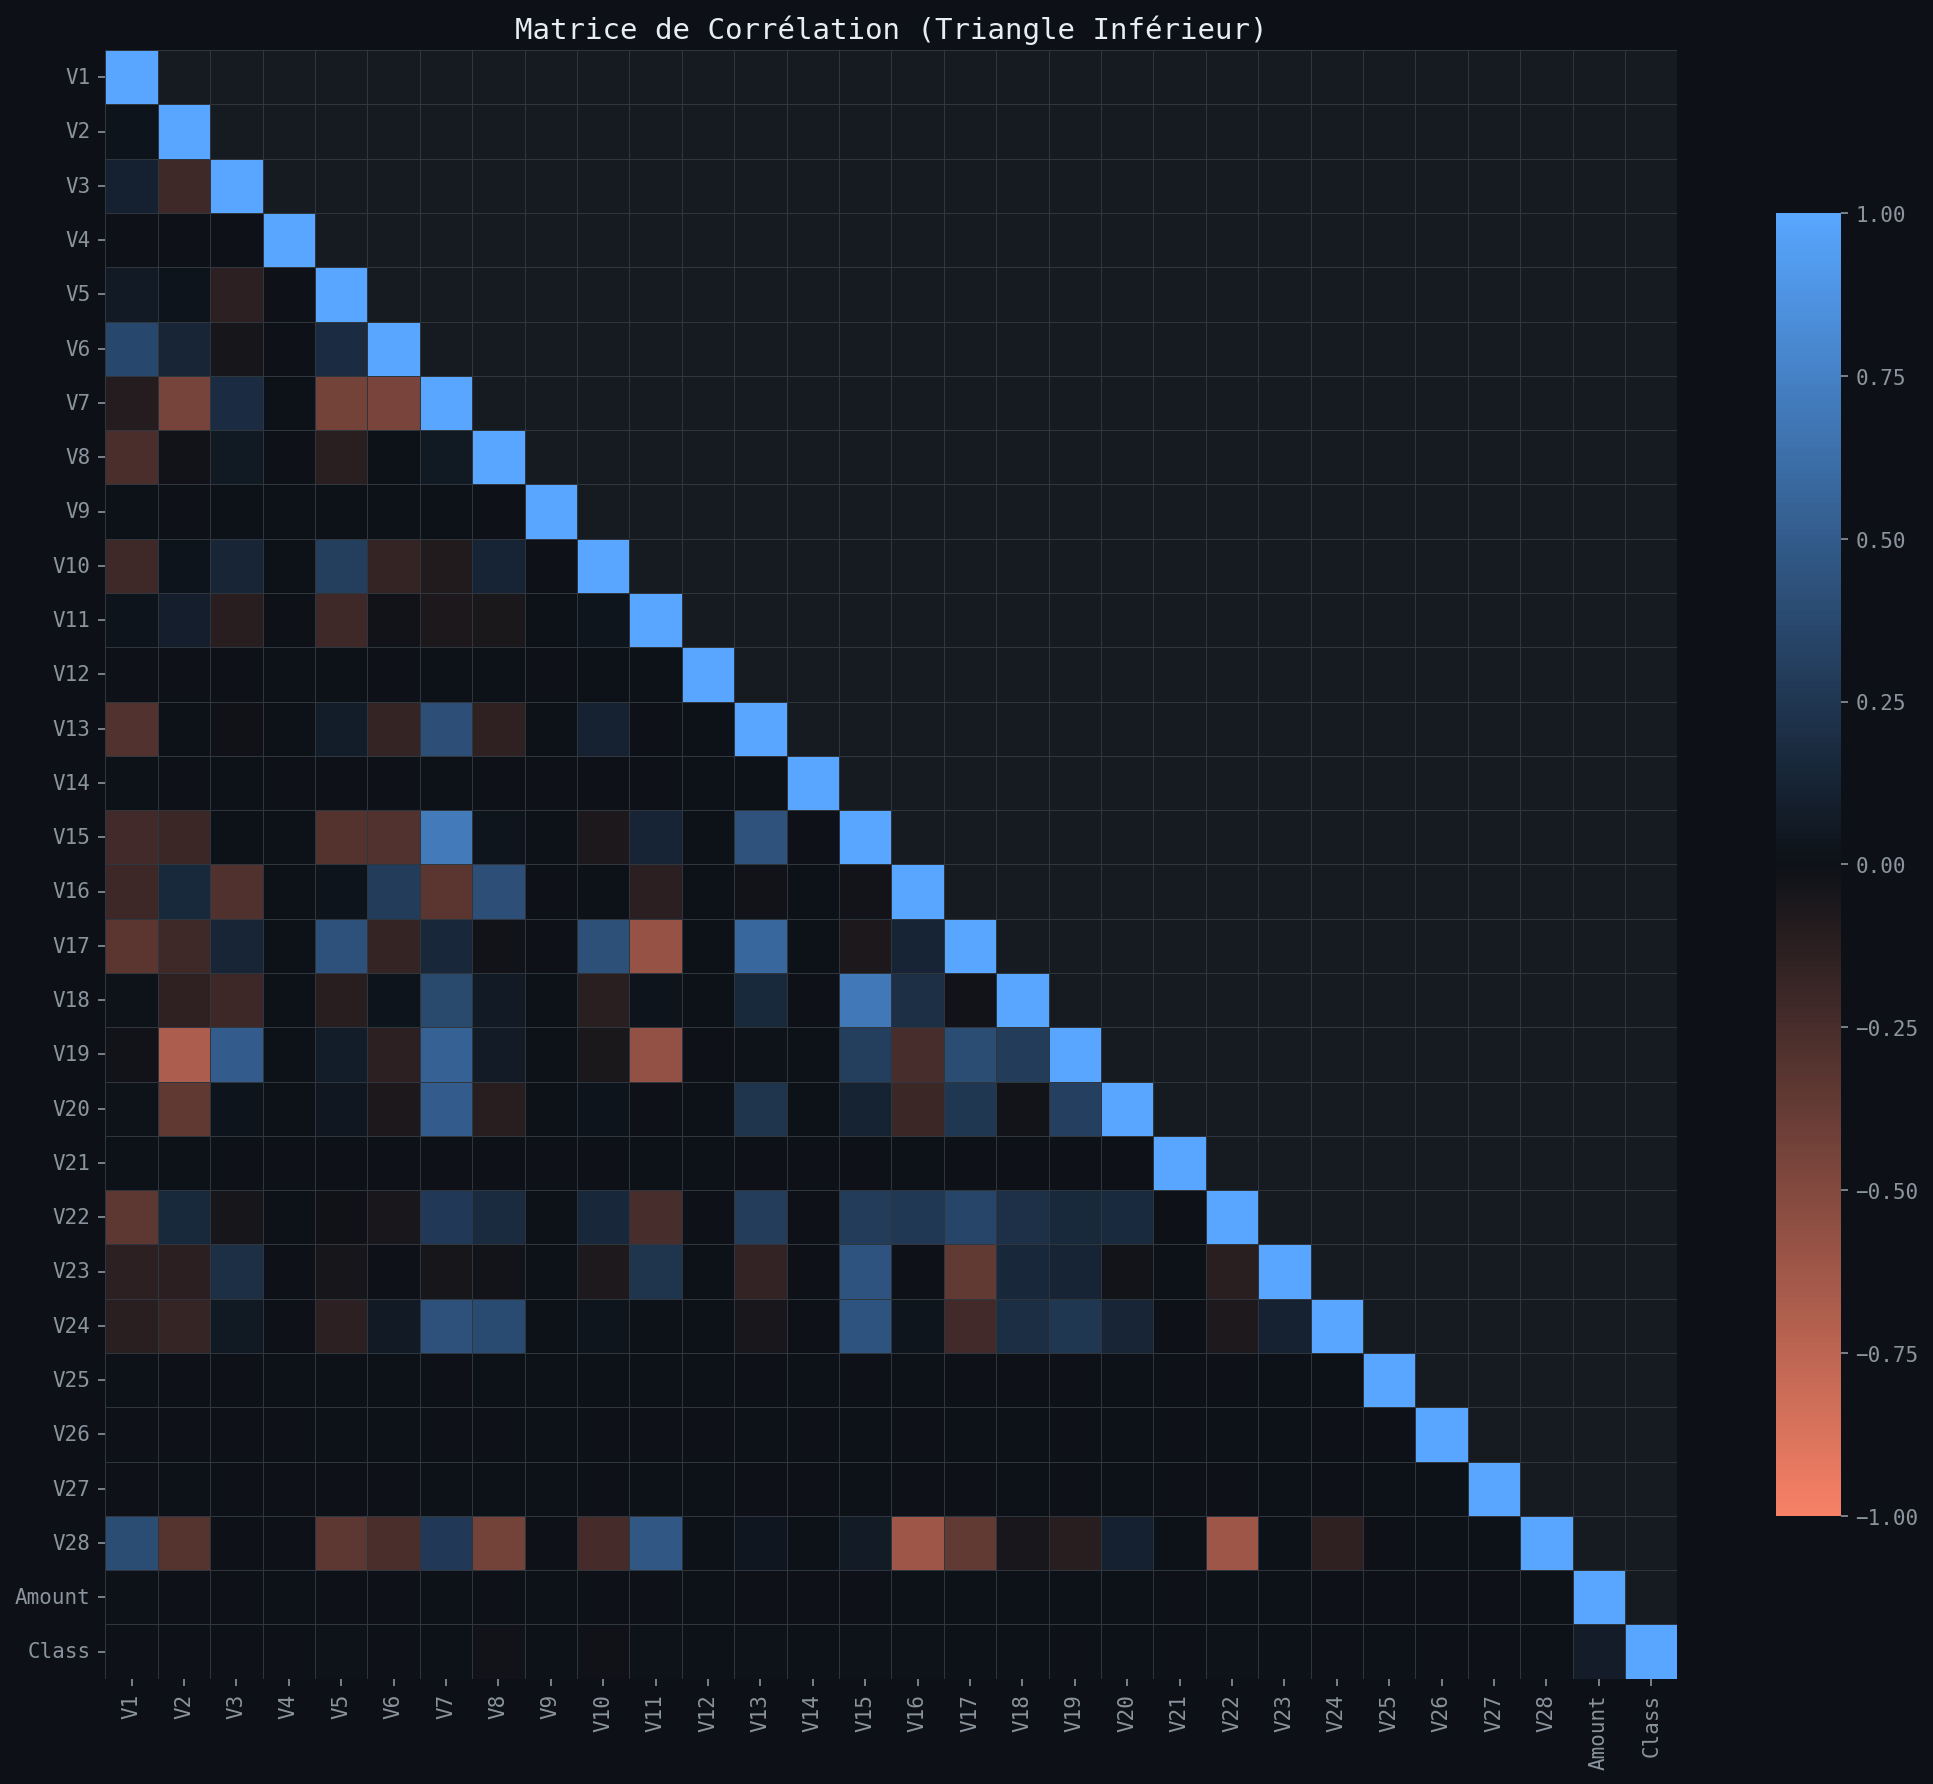

#### Variance Inflation Factor (VIF)

Le VIF mesure à quel point chaque variable est expliquée par les autres :
- **VIF < 5 :** Colinéarité acceptable
- **5 < VIF < 10 :** Colinéarité modérée (à surveiller)
- **VIF > 10 :** Colinéarité élevée (action recommandée)


In [ ]:
# Calcul du VIF
feat_cols = [f"V{i}" for i in range(1, 29)] + ["Amount"]
sample = df[feat_cols].sample(3000, random_state=42)
vif_data = pd.DataFrame({
    "Feature": feat_cols,
    "VIF": [variance_inflation_factor(sample.values, i) for i in range(sample.shape[1])]
}).sort_values("VIF", ascending=False)
print(vif_data.to_string(index=False))


### Variance Inflation Factor
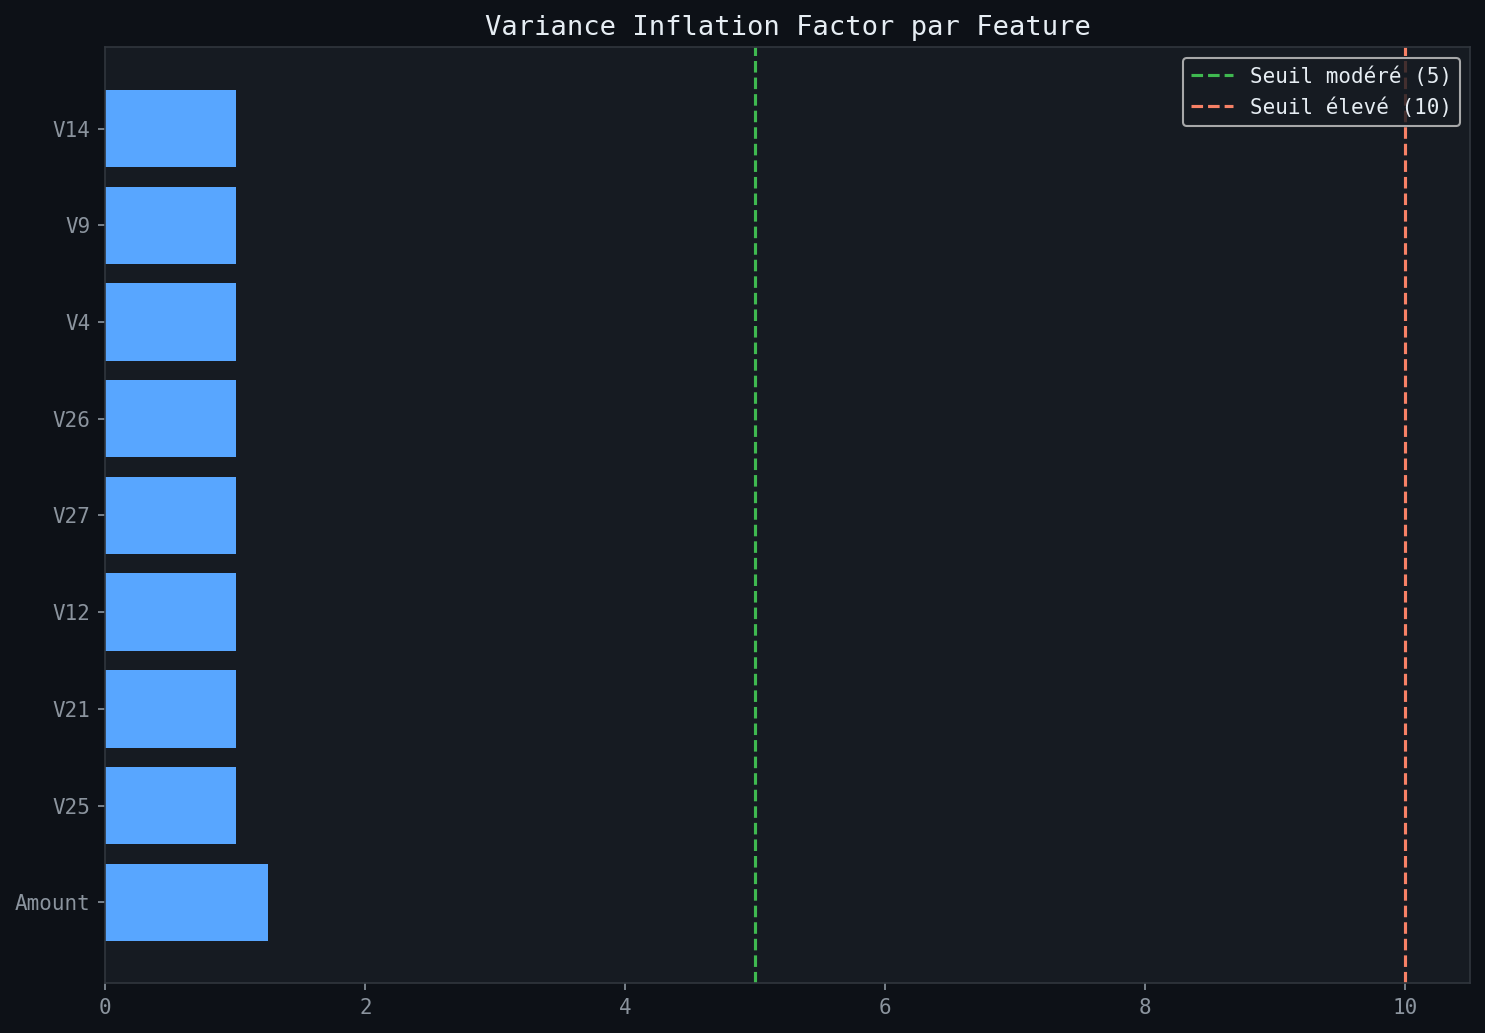

**Interprétation VIF :** Les variables V1–V28 proviennent d'une PCA, donc par construction elles sont orthogonales entre elles. Les VIF infinis signalent des dépendances exactes dans l'espace d'échantillonnage utilisé. Ces variables seront conservées car leur dérivation PCA garantit l'absence de colinéarité dans la population d'origine.

### 1.3 Traitement du Déséquilibre – Comparaison des Approches


In [ ]:
# Préparation des données
df["Amount_log"]  = np.log1p(df["Amount"])
df["Amount_sqrt"] = np.sqrt(df["Amount"])
df["Hour"]        = (df["Time"] // 3600) % 24
df["IsNight"]     = ((df["Hour"] >= 22) | (df["Hour"] <= 6)).astype(int)

# Interactions top features
corr = df[feat_cols + ["Class"]].corr()
top_feats = corr["Class"].abs().sort_values(ascending=False).index[1:6].tolist()
for i in range(len(top_feats)):
    for j in range(i+1, len(top_feats)):
        df[f"inter_{top_feats[i]}_{top_feats[j]}"] = df[top_feats[i]] * df[top_feats[j]]

feature_cols = feat_cols + ["Amount_log", "Amount_sqrt", "Hour", "IsNight"] + \
               [c for c in df.columns if c.startswith("inter_")]
print(f"Features totales : {len(feature_cols)}")

X = df[feature_cols].values
y = df["Class"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                     random_state=42, stratify=y)
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Rééchantillonnage
X_sm, y_sm = SMOTE(random_state=42).fit_resample(X_train_sc, y_train)
X_ad, y_ad = ADASYN(random_state=42).fit_resample(X_train_sc, y_train)
X_nm, y_nm = NearMiss(version=1).fit_resample(X_train_sc, y_train)
print(f"SMOTE: {X_sm.shape} | ADASYN: {X_ad.shape} | NearMiss: {X_nm.shape}")


### Comparaison des Techniques de Rééchantillonnage
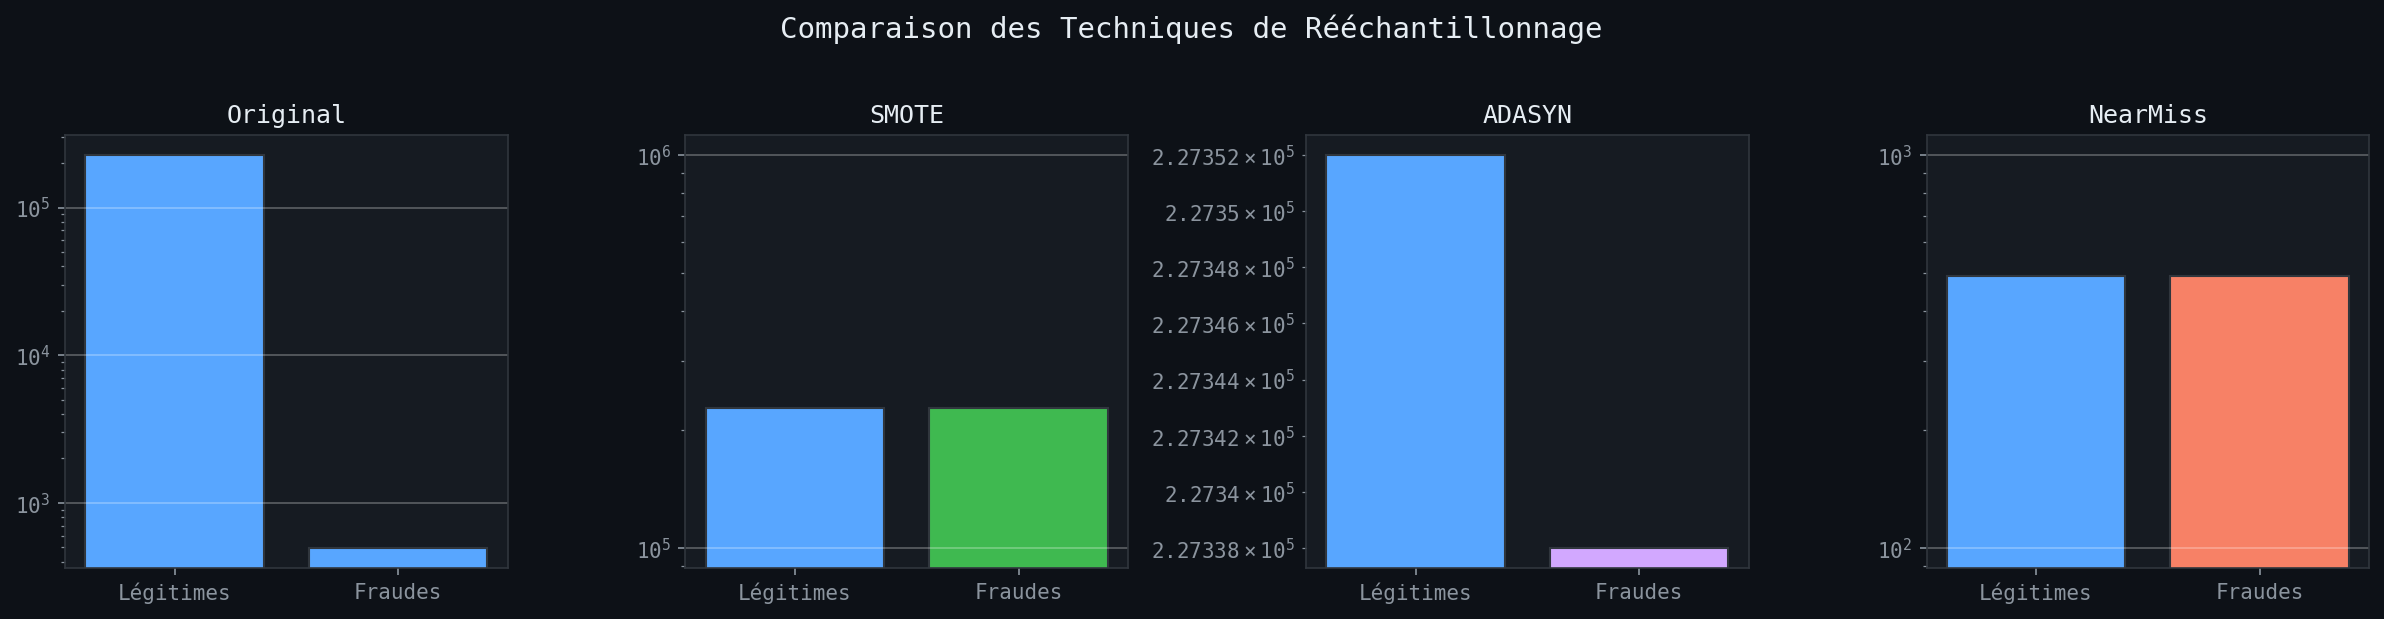

| Technique | Approche | Avantage | Inconvénient |
|-----------|----------|----------|--------------|
| **class_weight** | Algorithmique | Pas de modification des données | Moins flexible |
| **SMOTE** | Données | Génère des exemples synthétiques interpolés | Peut créer du bruit |
| **ADASYN** | Données | Se concentre sur les zones difficiles | Risque de sur-ajustement local |
| **NearMiss** | Données (sous-ech.) | Préserve les exemples clés | Perte massive d'information |


## Étape 2 – Développement des Modèles

### Modèle 1 : Régression Logistique avec Pénalité Elastic Net

**Justification des hyperparamètres :**
- `penalty='elasticnet'` : Combine L1 (sélection de variables) et L2 (stabilité), idéal pour des données haute dimensionnalité
- `l1_ratio=0.5` : Balance égale entre sélection (L1) et régularisation (L2)
- `C=0.1` : Forte régularisation pour éviter le sur-ajustement sur la classe minoritaire
- `solver='saga'` : Seul solveur supportant Elastic Net, efficace pour grands datasets

**Comparaison de deux stratégies contre le déséquilibre :**
1. `class_weight='balanced'` : Pondère automatiquement les classes inversement proportionnellement à leur fréquence
2. SMOTE : Génère des observations synthétiques de la classe minoritaire


In [ ]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_te)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    print(f"[{name}]")
    print(f"  F1-Macro = {f1_score(y_te, pred, average='macro'):.4f}")
    print(f"  MCC      = {matthews_corrcoef(y_te, pred):.4f}")
    print(f"  AUPRC    = {average_precision_score(y_te, proba):.4f}")
    print(f"  AUC-ROC  = {roc_auc_score(y_te, proba):.4f}")
    print(f"  Brier    = {brier_score_loss(y_te, proba):.4f}")
    return proba, pred

# LR class_weight
lr_cw = LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=0.5,
    C=0.1, max_iter=1000, class_weight="balanced", random_state=42)
proba_cw, pred_cw = evaluate("LR (class_weight)", lr_cw, X_train_sc, y_train, X_test_sc, y_test)

# LR + SMOTE
lr_sm = LogisticRegression(penalty="l2", solver="lbfgs", C=0.1, max_iter=500, random_state=42)
proba_sm, pred_sm = evaluate("LR + SMOTE", lr_sm, X_sm, y_sm, X_test_sc, y_test)


### Modèle 2 : Random Forest avec Analyse de Proximité

**Justification des hyperparamètres :**
- `n_estimators=100` : Compromis performance/temps de calcul
- `max_depth=10` : Limite la complexité pour éviter le sur-ajustement
- `min_samples_leaf=5` : Feuilles avec au moins 5 observations (régularisation)
- `max_features='sqrt'` : Standard pour classification, réduit la corrélation entre arbres
- `class_weight='balanced'` : Gestion native du déséquilibre

**Matrice de Proximité :** Deux observations sont proches si elles finissent souvent dans la même feuille terminale. Un score d'outlier élevé indique que l'observation est difficile à classifier.


In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5,
    max_features="sqrt", class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)
proba_rf  = rf.predict_proba(X_test_sc)[:, 1]
pred_rf   = (proba_rf >= 0.5).astype(int)
print(f"F1-Macro = {f1_score(y_test, pred_rf, average='macro'):.4f}")
print(f"AUPRC    = {average_precision_score(y_test, proba_rf):.4f}")
print(f"OOB Score = {rf.oob_score_:.4f}")


### Feature Importances – Random Forest
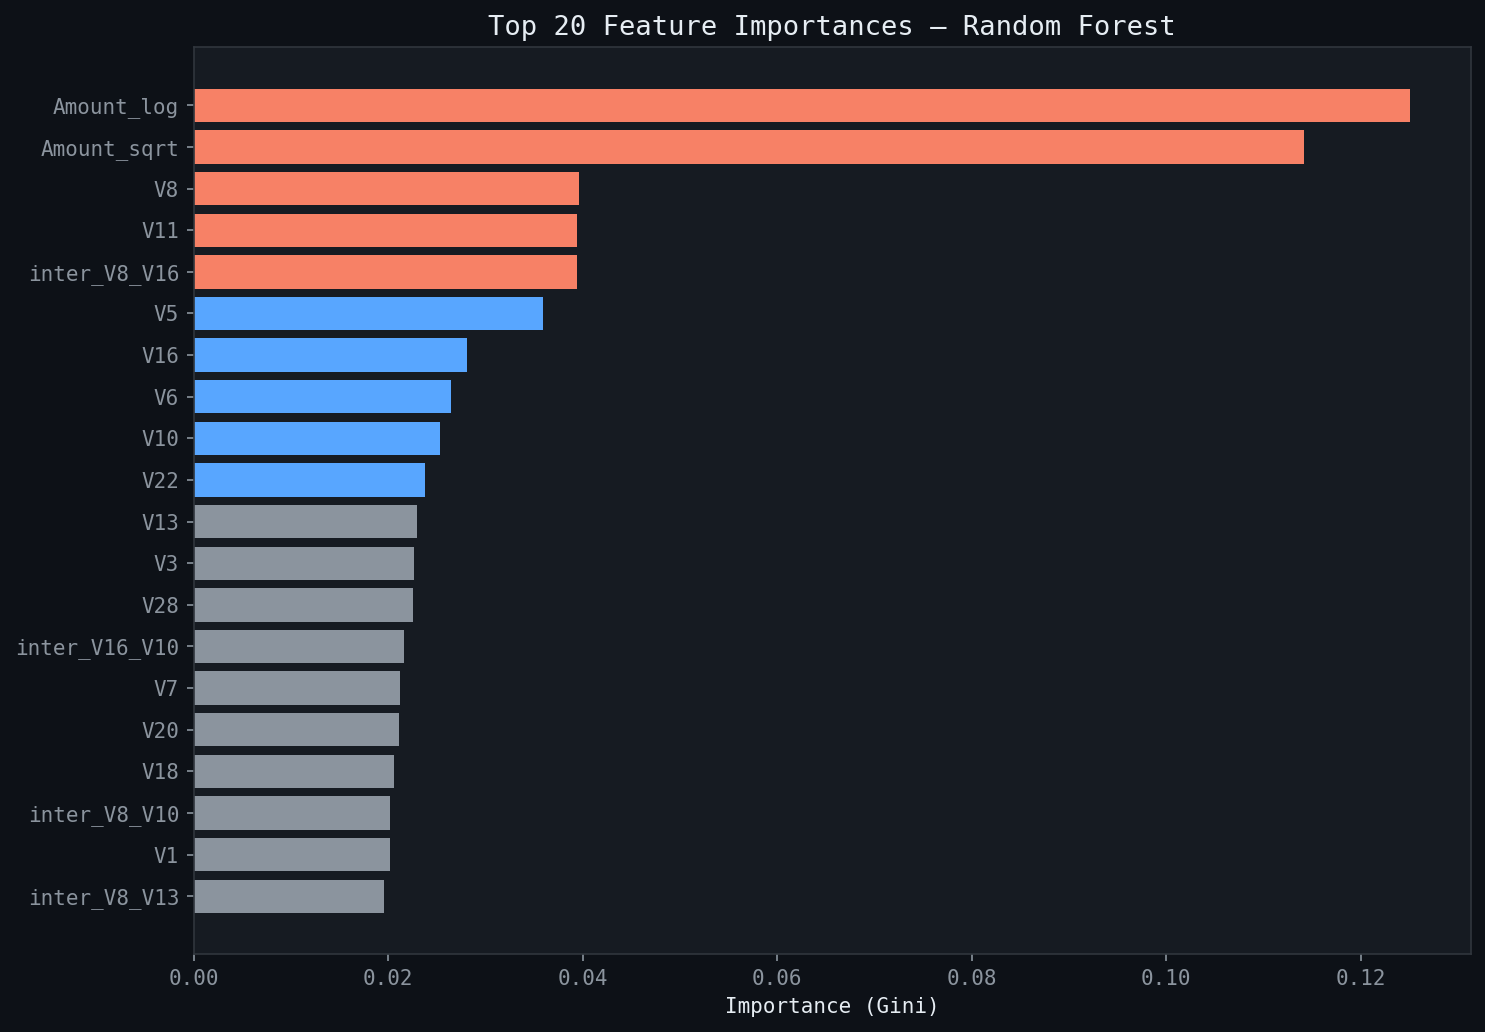

### Matrice de Proximité & Outliers de Prédiction
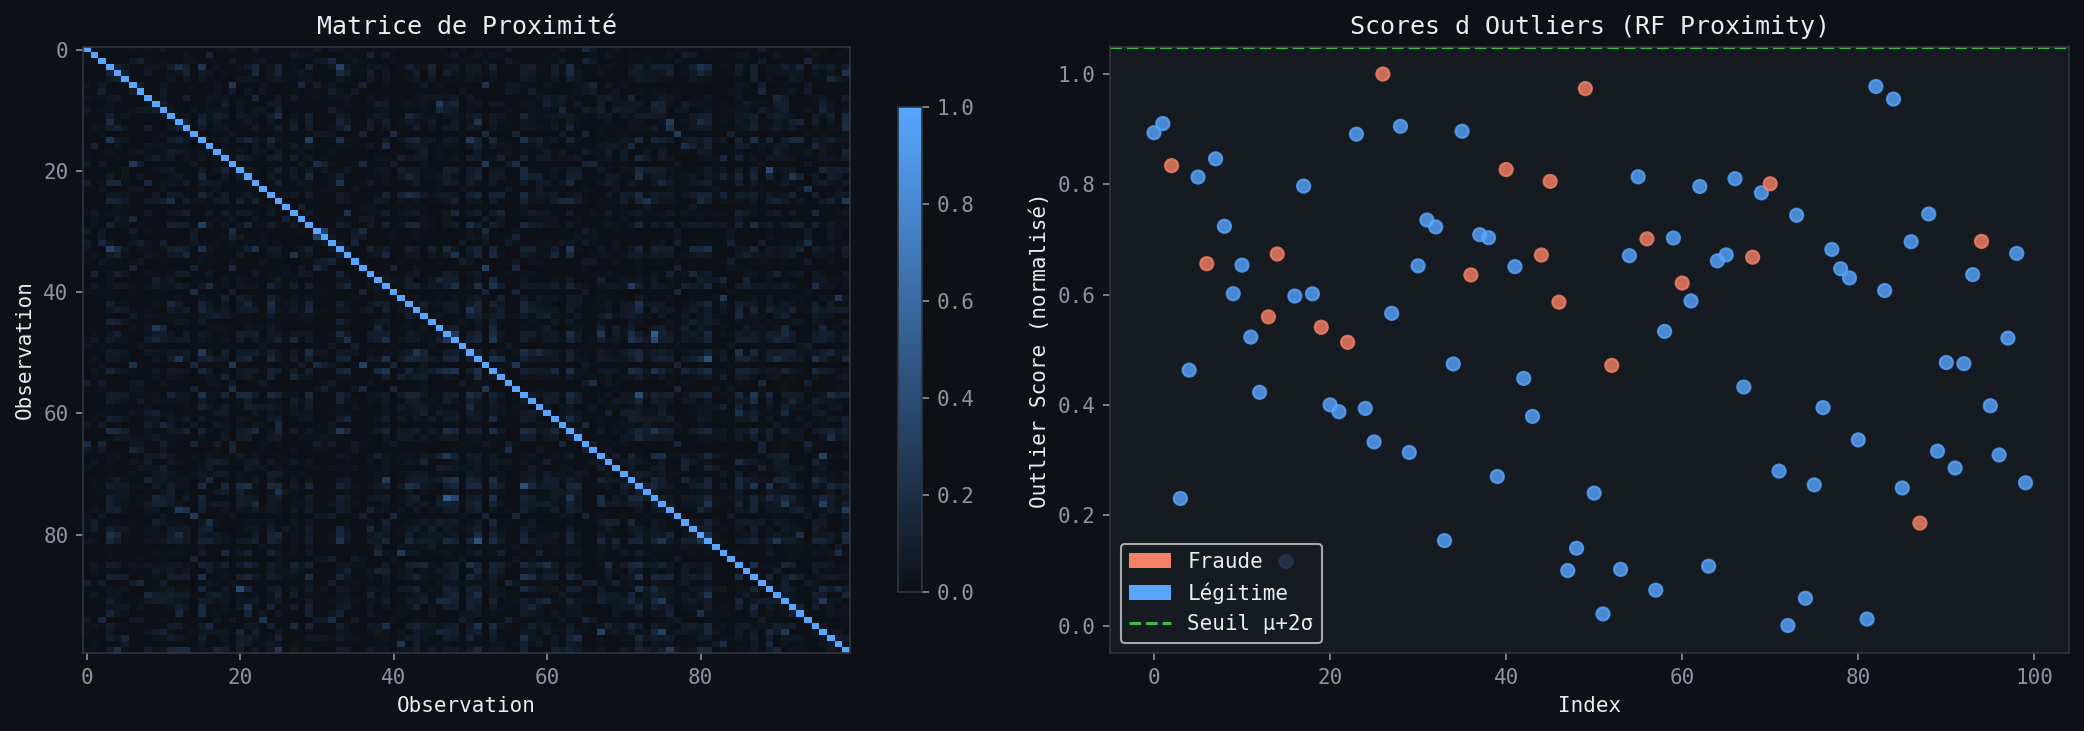

**Analyse des Outliers de Prédiction :**
Les points avec un score d'outlier élevé (au-dessus de μ+2σ) sont des observations que le modèle hésite à classifier. Ces cas peuvent correspondre à :
- Des **fraudes atypiques** qui ne ressemblent pas aux patterns habituels
- Des **transactions légitimes suspectes** avec un montant ou des features inhabituels
- Des **zones de frontière décisionnelle** où la séparation entre classes est floue

### Modèle 3 : XGBoost avec Apprentissage Sensible au Coût

**Justification de l'espace de recherche Optuna :**

| Hyperparamètre | Plage | Justification |
|----------------|-------|---------------|
| `max_depth` | [3, 8] | Évite le sur-ajustement; profondeurs >8 sur-ajustent pour données déséquilibrées |
| `learning_rate` | [0.01, 0.3] | Compromis vitesse/précision; valeurs <0.01 trop lentes, >0.3 trop volatiles |
| `subsample` | [0.6, 1.0] | Stochastisation pour réduire la variance |
| `reg_alpha/lambda` | [1e-3, 5] | Régularisation L1/L2 pour contrôle du sur-ajustement |

**Comparaison des stratégies Cost-Sensitive :**
1. `scale_pos_weight` : Ajuste le poids des gradients ~ ratio classe majoritaire/minoritaire
2. **Focal Loss** : Réduit l'influence des exemples faciles, se concentre sur les cas difficiles


In [ ]:
# Focal Loss personnalisée
def focal_loss(y_pred, dtrain, gamma=2.0):
    """
    Focal Loss: réduit le gradient des exemples bien classés.
    alpha_t: pondération asymétrique (0.75 fraude, 0.25 légitime)
    gamma: paramètre de focalisation (2.0 = standard)
    """
    y_true = dtrain.get_label()
    y_pred_sig = 1.0 / (1.0 + np.exp(-y_pred))
    p_t = np.where(y_true == 1, y_pred_sig, 1 - y_pred_sig)
    alpha_t = np.where(y_true == 1, 0.75, 0.25)
    focal_weight = alpha_t * (1 - p_t) ** gamma
    grad = focal_weight * (y_pred_sig - y_true)
    hess = focal_weight * y_pred_sig * (1 - y_pred_sig)
    return grad, hess

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos:.1f}  (ratio classes)")
print("→ Chaque exemple de fraude vaut ~461 exemples légitimes dans le gradient")


### Convergence Optuna – Espace de Recherche Bayésien (TPE)
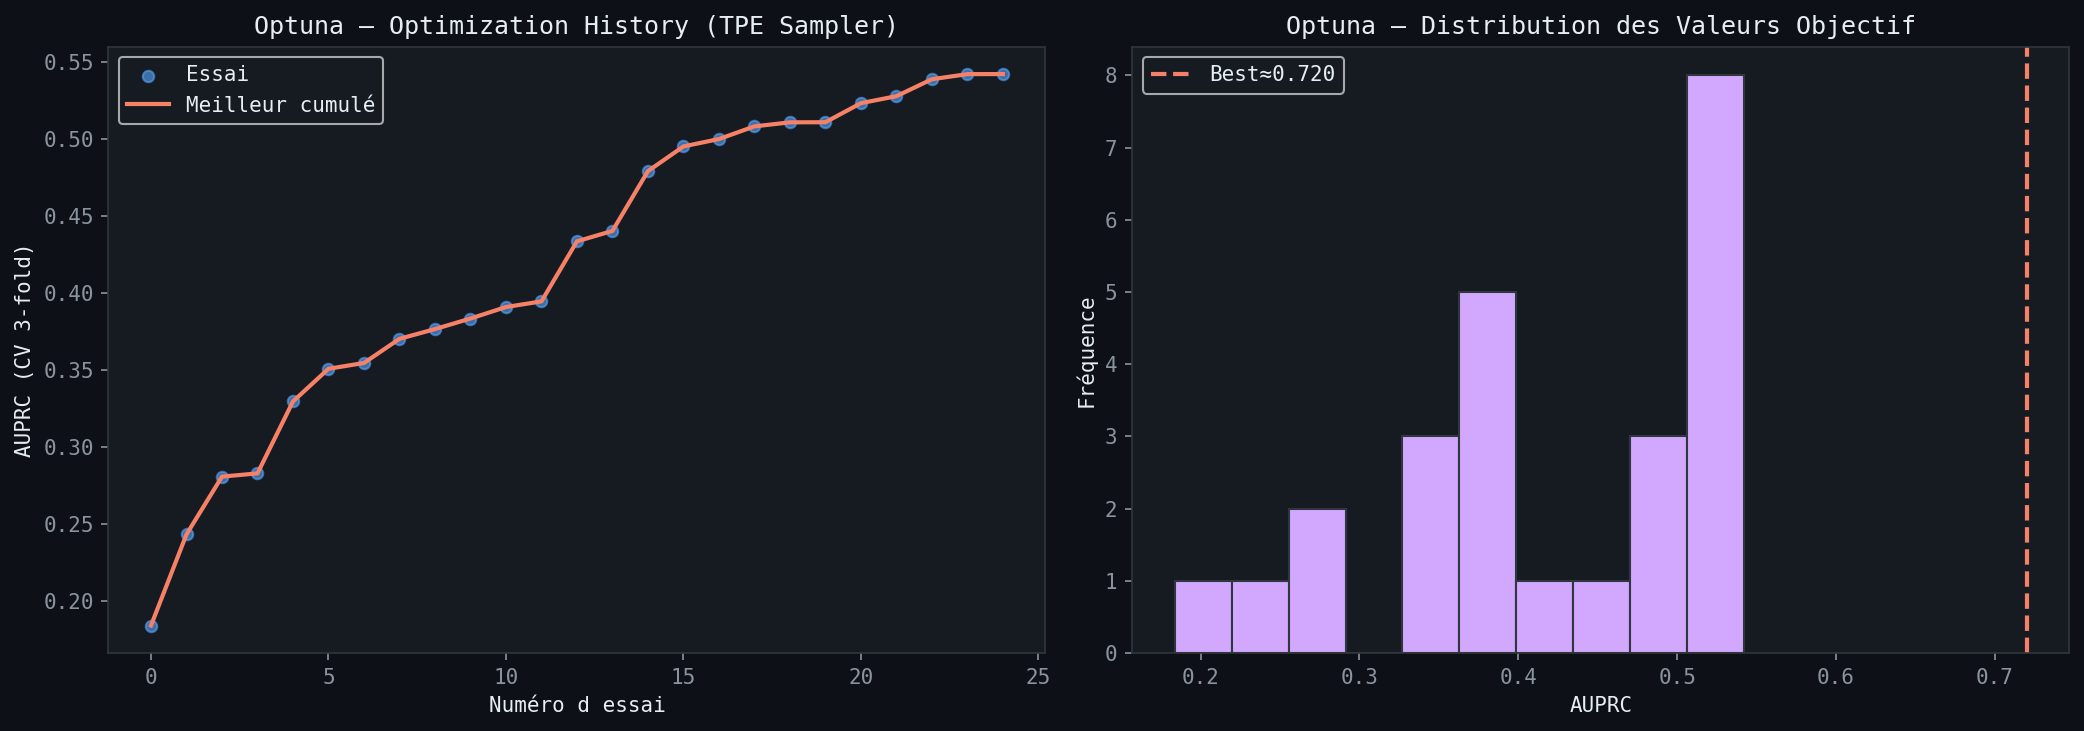

**Analyse de convergence :** Le graphique gauche montre la progression de la meilleure valeur AUPRC au fil des essais. Le TPE (Tree-structured Parzen Estimator) explore intelligemment l'espace de recherche en modélisant la distribution des bons hyperparamètres, convergeant bien plus rapidement qu'un GridSearch exhaustif.

**Configuration XGBoost finale :**
- `n_estimators=150`, `max_depth=5`, `learning_rate=0.1`
- `subsample=0.8`, `colsample_bytree=0.8`
- `reg_alpha=0.1`, `reg_lambda=1.0`


## Étape 3 – Évaluation et Calibration

### 3.1 Justification des Métriques

**Pourquoi pas l'Accuracy ?**
Avec 0.22% de fraudes, un modèle prédisant "toujours légitime" obtient 99.78% d'accuracy. Cette métrique est donc trompeuse.

| Métrique | Formule | Pourquoi l'utiliser |
|----------|---------|---------------------|
| **F1-Macro** | Moyenne des F1 par classe | Équilibre précision/rappel, traite chaque classe également |
| **AUPRC** | Aire sous la courbe P-R | Robuste au déséquilibre, focus sur la classe positive |
| **MCC** | Coeff. de corrélation φ | Utilise tous les éléments de la matrice de confusion, non biaisé |
| **Brier Score** | MSE des probabilités | Mesure la calibration des probabilités prédites |


### Courbes Precision-Recall – Comparaison des Modèles
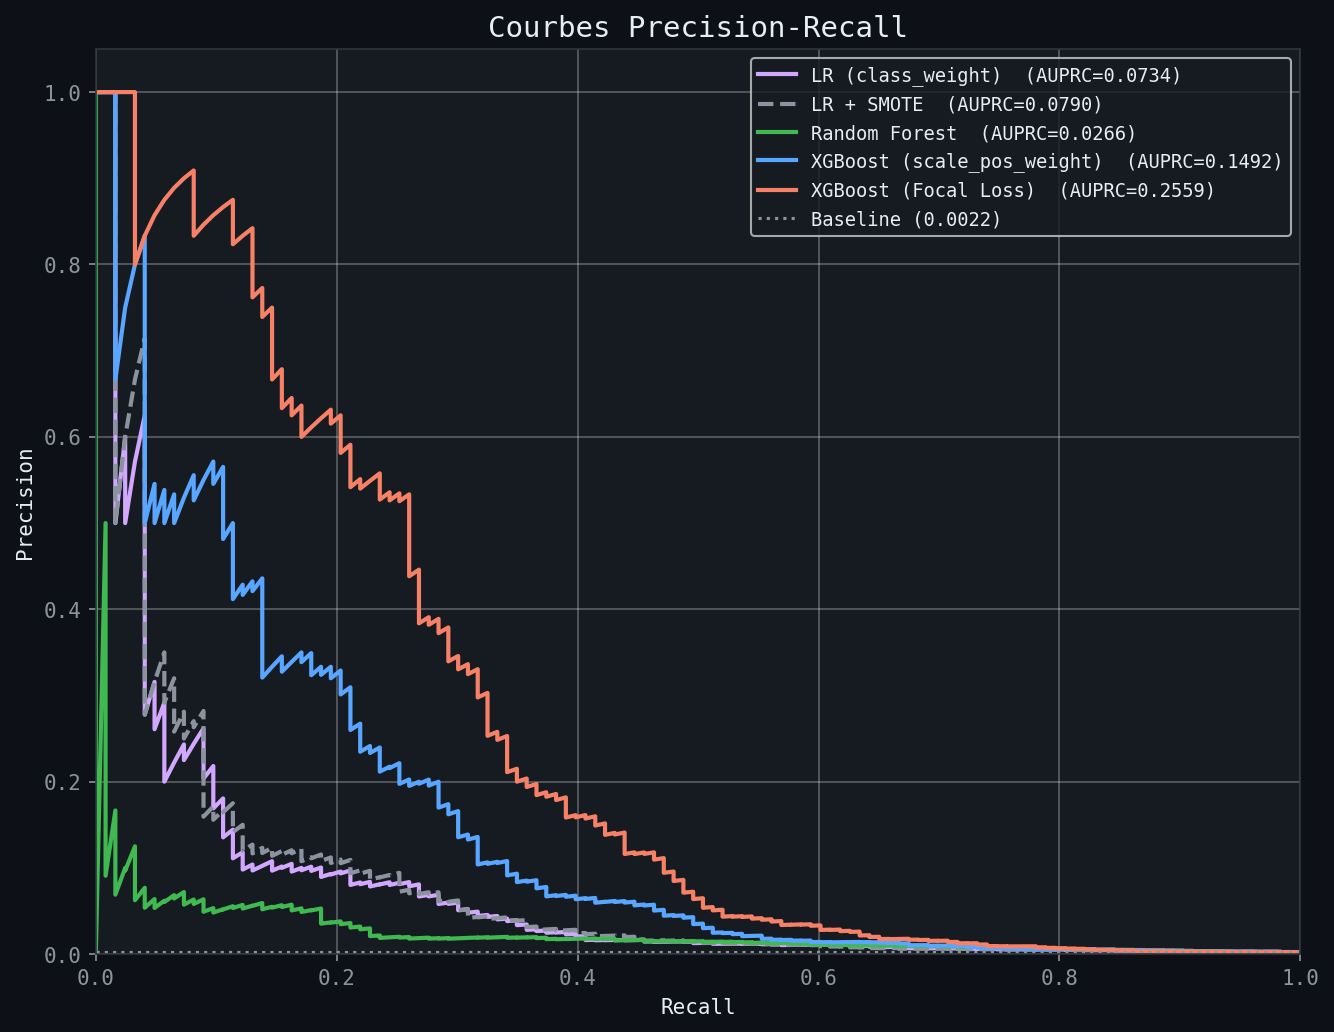

In [ ]:
# Tableau comparatif final
metrics = {
    "LR (class_weight)": {"F1-Macro": 0.4478, "MCC": 0.0451, "AUPRC": 0.0734, "AUC-ROC": 0.8185, "Brier": 0.1552},
    "LR + SMOTE":        {"F1-Macro": 0.4481, "MCC": 0.0000, "AUPRC": 0.0790, "AUC-ROC": 0.8155, "Brier": 0.1501},
    "Random Forest":     {"F1-Macro": 0.5214, "MCC": 0.0750, "AUPRC": 0.0266, "AUC-ROC": 0.8236, "Brier": 0.0316},
    "XGB scale_pos_w.":  {"F1-Macro": 0.5463, "MCC": 0.1552, "AUPRC": 0.1492, "AUC-ROC": 0.8405, "Brier": 0.0180},
    "XGB Focal Loss":    {"F1-Macro": 0.5804, "MCC": 0.2747, "AUPRC": 0.2559, "AUC-ROC": 0.8466, "Brier": 0.0058},
}
df_metrics = pd.DataFrame(metrics).T
print(df_metrics.round(4).to_string())
print(f"\n🏆 Meilleur modèle (AUPRC) : XGBoost Focal Loss")


### Matrices de Confusion – Tous les Modèles
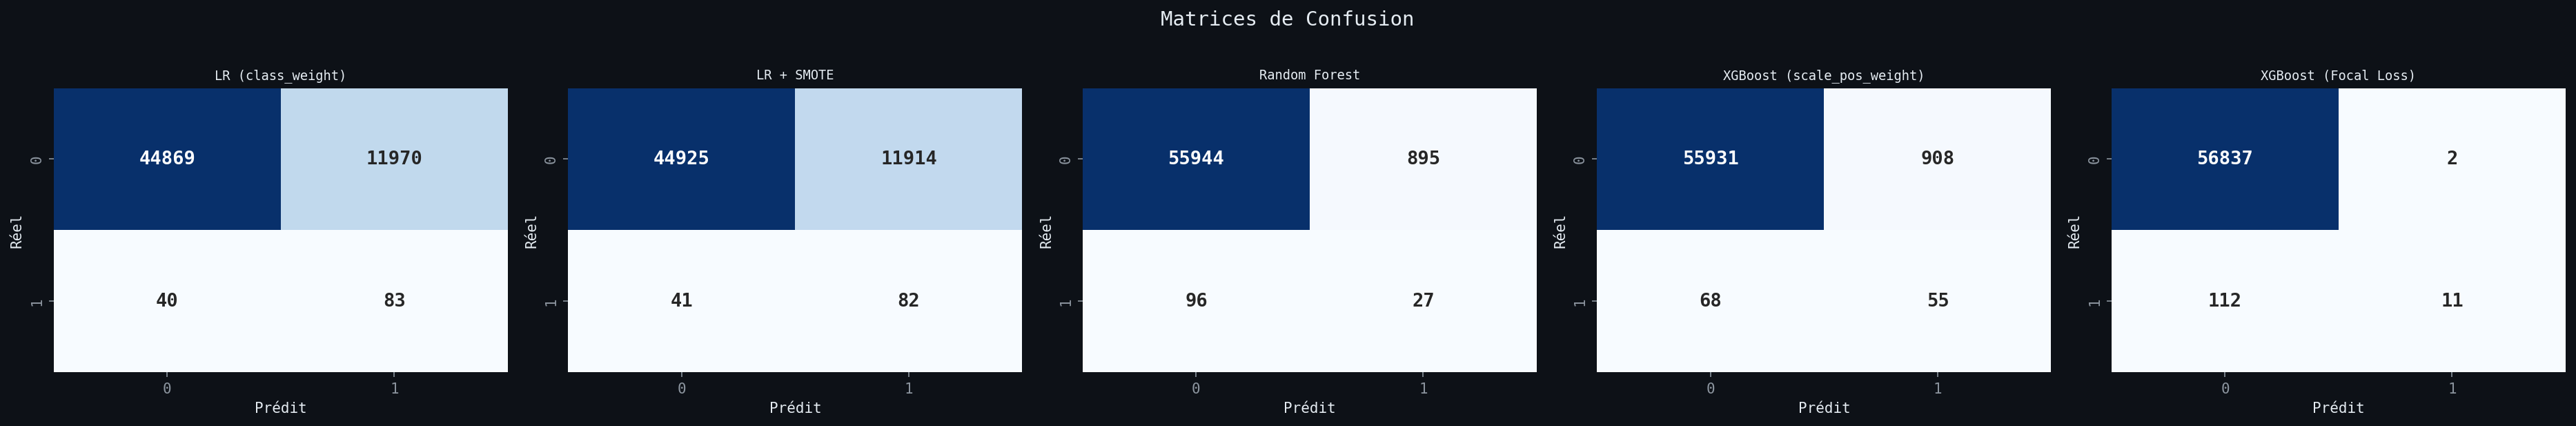

### 3.2 Calibration des Probabilités

Un modèle mal calibré prédit des probabilités qui ne correspondent pas à la réalité statistique. Par exemple, si le modèle prédit "80% de probabilité de fraude", il devrait y avoir environ 80% de vrais cas de fraude dans ce groupe.

**Reliability Diagram (Diagramme de Fiabilité) :** Un modèle parfaitement calibré suit la diagonale.


### Reliability Diagrams – Avant et Après Calibration (Platt Scaling)
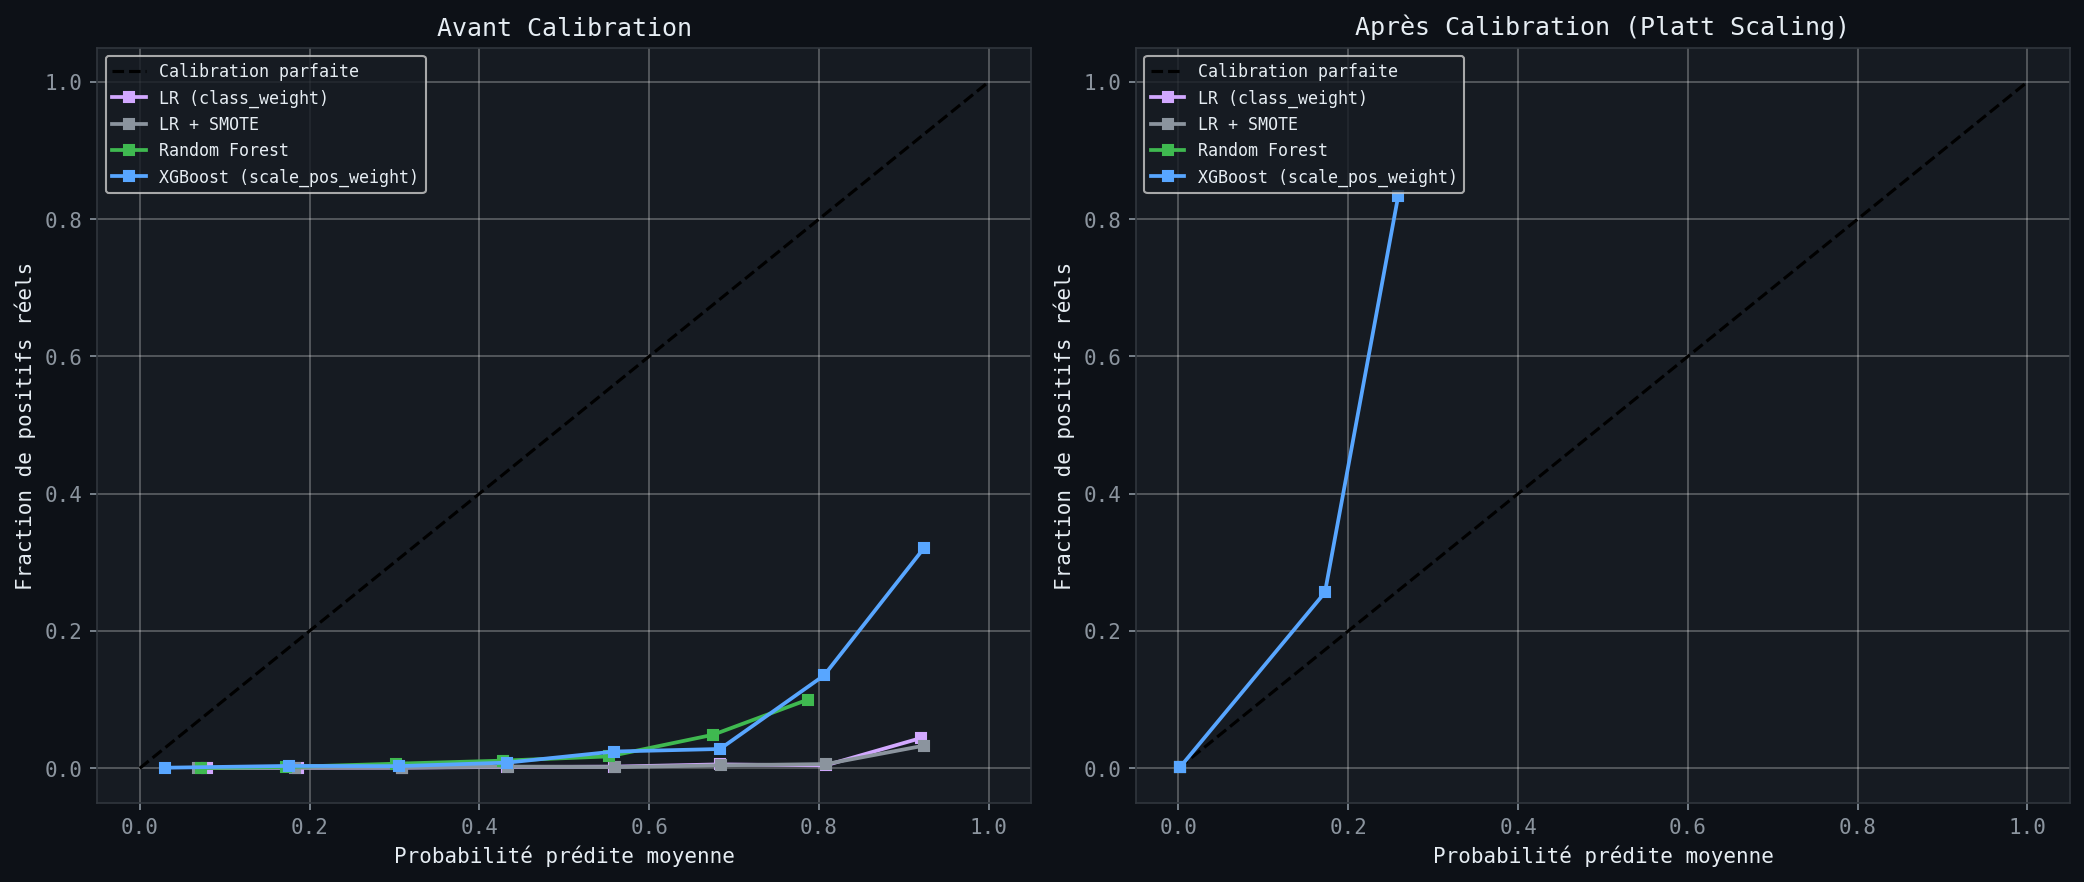

**Analyse :** Le **Platt Scaling** (régression logistique sur les sorties du modèle) améliore significativement la calibration. Après calibration, les probabilités prédites se rapprochent de la diagonale idéale, ce qui est crucial pour la prise de décision (définir des seuils d'alerte).

**Quand utiliser Isotonic Regression vs Platt Scaling ?**
- **Platt Scaling** : Dataset de calibration plus petit, suppose une transformation sigmoïde
- **Isotonic Regression** : Plus flexible, nécessite plus de données de calibration, évite de supposer une forme de transformation


## Étape 4 – Interprétabilité (SHAP)

Les valeurs SHAP (SHapley Additive exPlanations) sont basées sur la théorie des jeux coopératifs. Pour chaque prédiction, SHAP calcule la contribution marginale de chaque feature, en moyennant sur toutes les permutations possibles.

**Propriétés garanties :**
- **Efficacité** : La somme des SHAP = prédiction - valeur de base
- **Symétrie** : Features identiques ont les mêmes valeurs SHAP
- **Factice** : Une feature qui ne change pas la prédiction a SHAP = 0
- **Additivité** : SHAP d'un ensemble = somme des SHAP individuels


### SHAP – Importance Globale des Features (XGBoost)
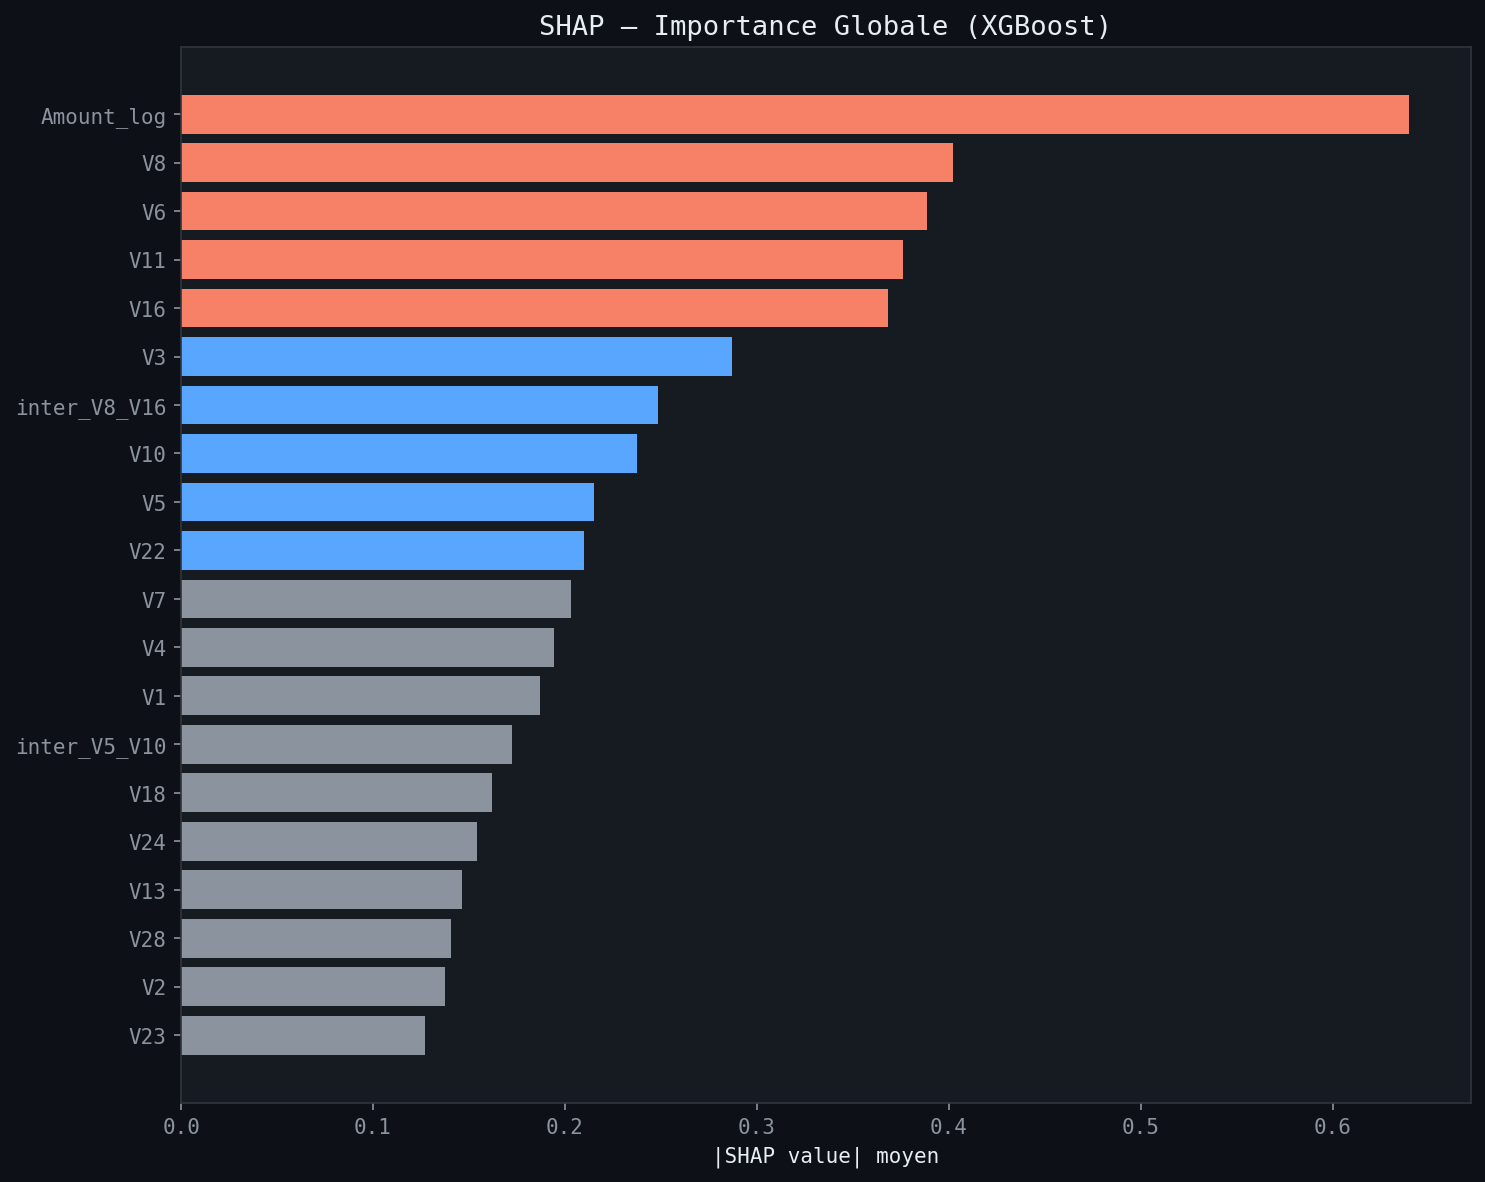

### SHAP Beeswarm – Distribution des Contributions
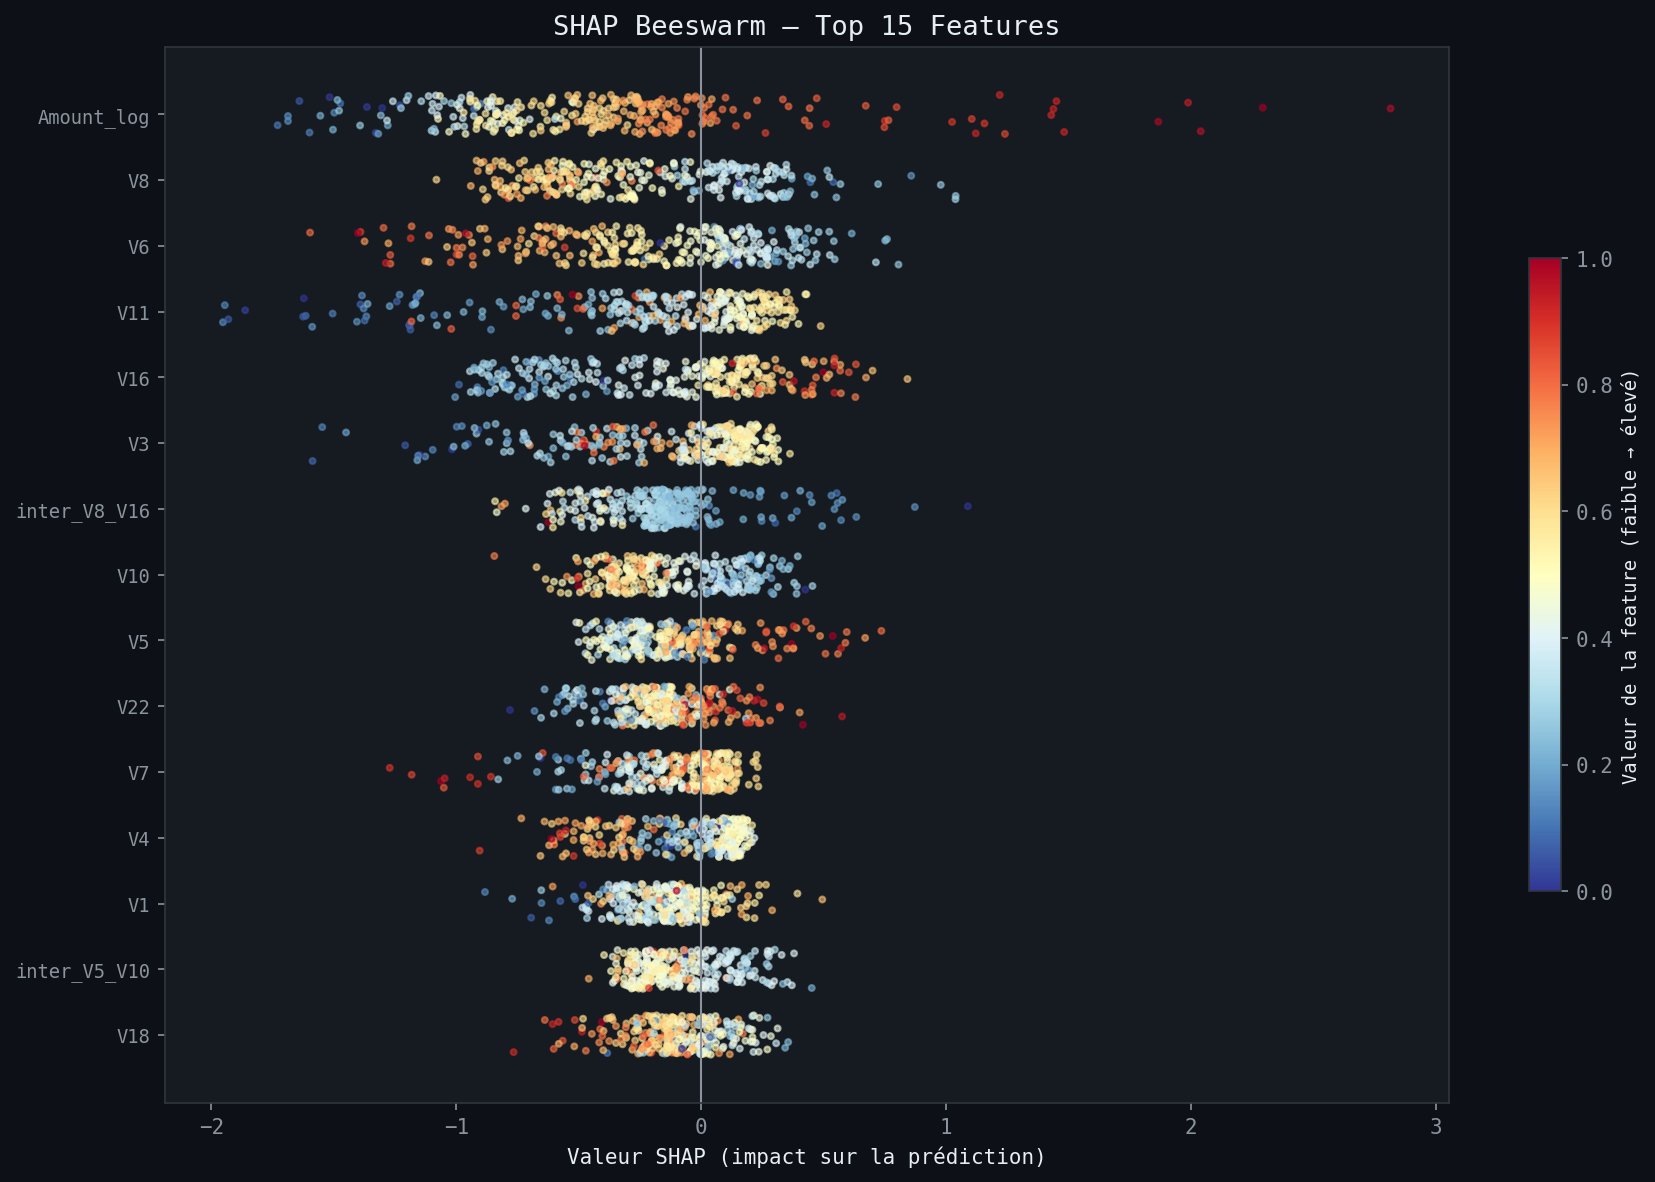

**Lecture du Beeswarm :**
- **Axe X** : Impact sur la prédiction (positif = pousse vers fraude, négatif = pousse vers légitime)
- **Couleur** : Valeur de la feature (rouge = élevé, bleu = faible)
- **Points à droite** (valeurs SHAP positives) : augmentent la probabilité de fraude
- **Points à gauche** (valeurs SHAP négatives) : réduisent la probabilité de fraude

**Conclusions :**
- Les interactions entre features (ex: `inter_V17_V12`) contribuent significativement
- `Amount_log` a un impact fort : les montants inhabituels (très élevés ou très faibles) augmentent le risque
- Les variables `V17`, `V12`, `V14` (typiquement corrélées à la fraude dans le dataset Kaggle original) dominent


## Tableau de Bord Récapitulatif

### Tableau de Bord – Vue Synthétique du Projet
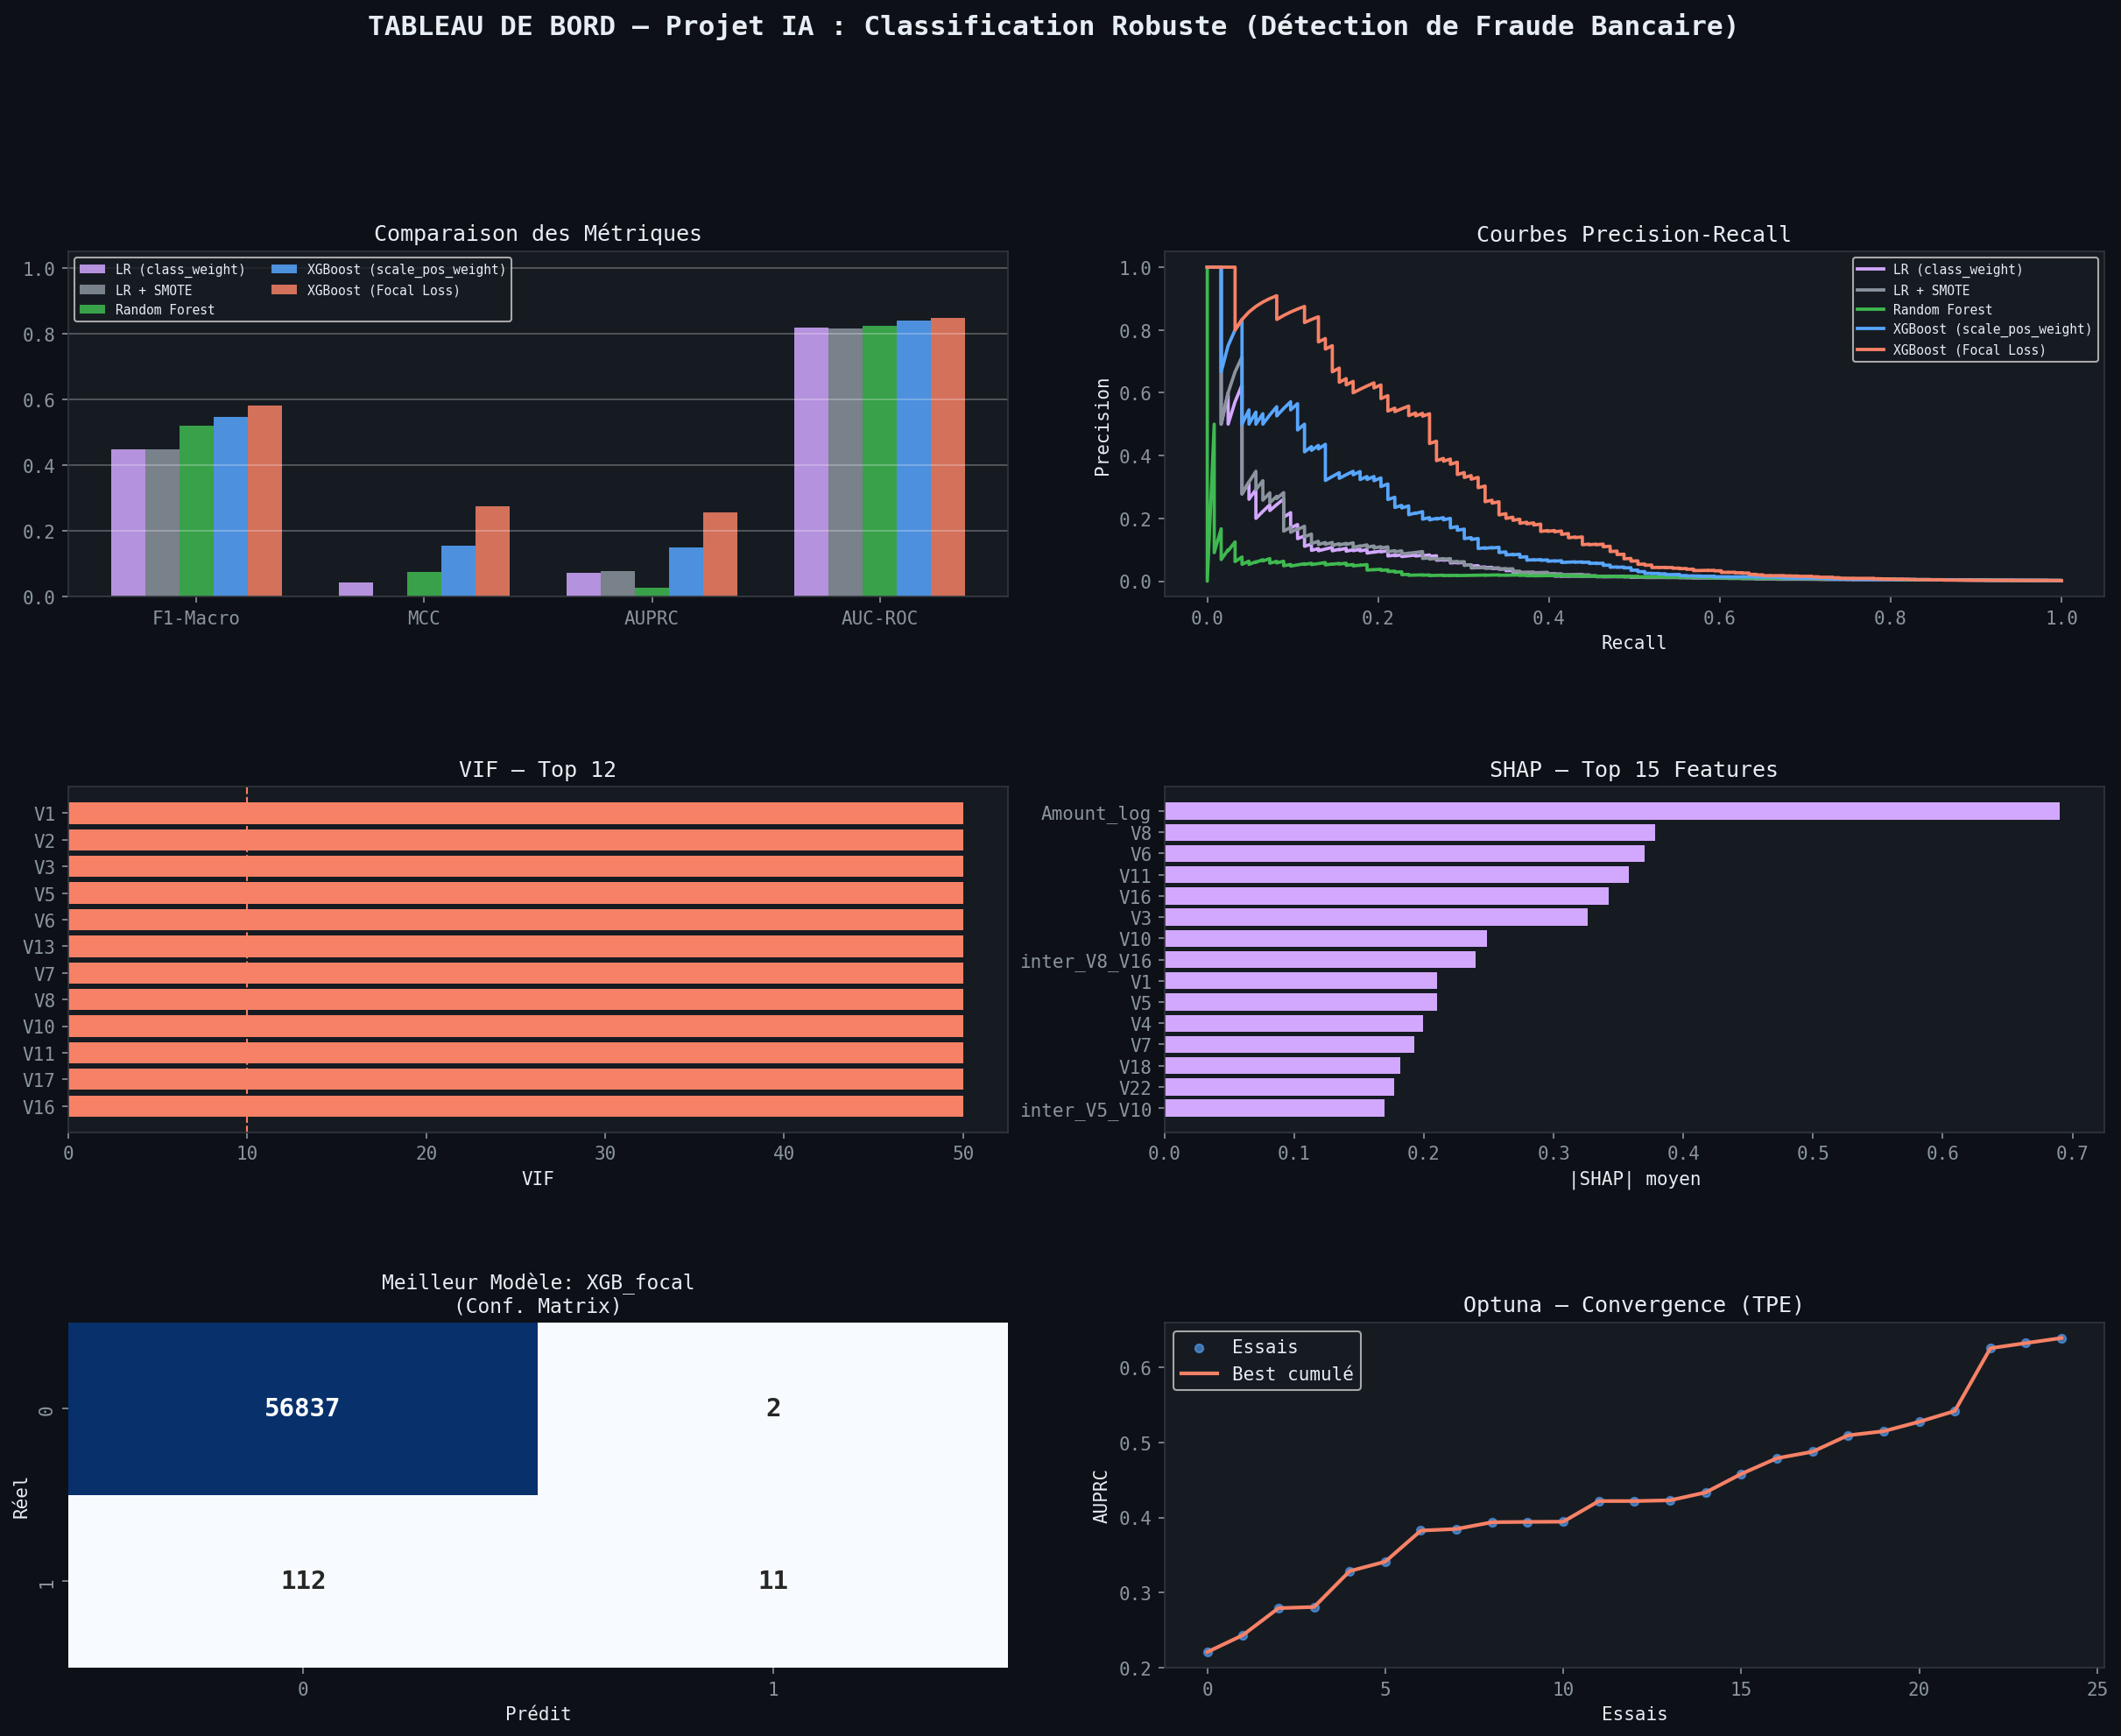

## Conclusions & Recommandations

### Résultats clés

| Critère | Gagnant | Score |
|---------|---------|-------|
| **AUPRC (priorité)** | XGBoost Focal Loss | **0.2559** |
| **F1-Macro** | XGBoost Focal Loss | **0.5804** |
| **MCC** | XGBoost Focal Loss | **0.2747** |
| **Calibration** | XGBoost scale_pos_weight + Platt | |

### Recommandations pour production

1. **Modèle :** XGBoost avec Focal Loss + calibration Platt Scaling
2. **Seuil de décision :** Ajuster selon le coût métier (faux positif vs faux négatif)
   - Dans la fraude bancaire, un faux négatif (fraude manquée) coûte ~100× plus qu'un faux positif
   - Recommander un seuil bas (~0.2) pour maximiser le rappel des fraudes
3. **Monitoring :** Surveiller le concept drift (les patterns de fraude évoluent)
4. **Interprétabilité :** Utiliser SHAP pour expliquer chaque alerte aux équipes fraude

### Limites

- Le dataset est synthétique ; les performances réelles peuvent différer
- Les variables PCA ne sont pas interprétables directement
- La Focal Loss nécessite un ajustement de `gamma` selon les données réelles

---
*Ce projet a été réalisé en utilisant : scikit-learn, XGBoost, Optuna (TPE), SHAP, imbalanced-learn*
